In [1]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import pdf_objetivo_ars, ln_pdf_objetivo_ars, ln_pdf_objetivo_prima_ars, ln_pdf_envolvente_ars, funcion_compresion_ars

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

Cloning into 'MCMC-MonteCarlo-TFG'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 436 (delta 61), reused 4 (delta 4), pack-reused 319 (from 2)
Receiving objects: 100% (436/436), 7.72 MiB | 26.34 MiB/s, done.
Resolving deltas: 100% (214/214), done.


In [2]:
nodos_x = np.array([-0.5, 0.5, 1.5, 2.5])
nodos_y = ln_pdf_objetivo_ars(nodos_x)
nodos_dy = ln_pdf_objetivo_prima_ars(nodos_x)

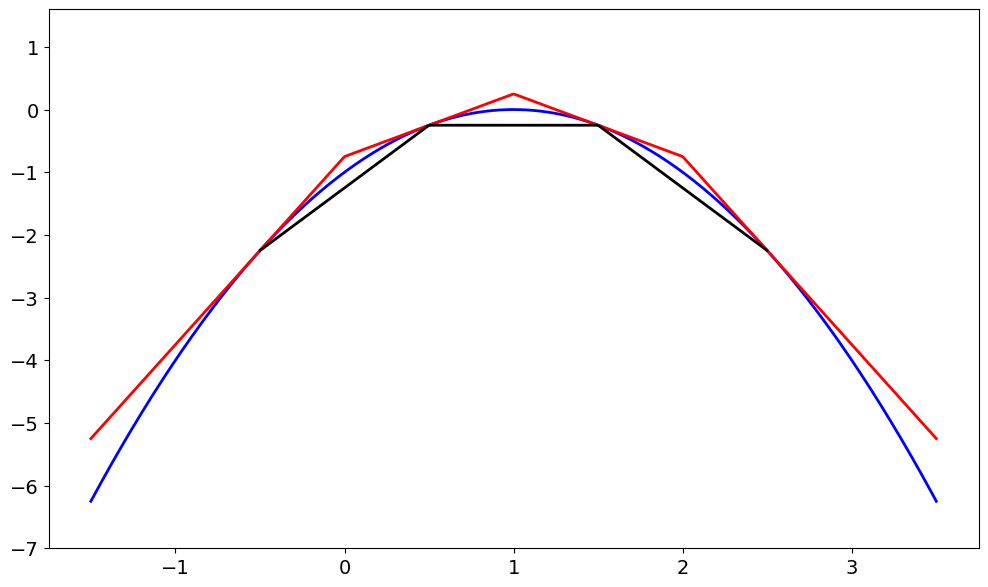

In [8]:
plt.figure(figsize=(12, 7))

x_grafico = np.linspace(-1.5, 3.5, 500)

plt.plot(x_grafico, ln_pdf_objetivo_ars(x_grafico), color='blue', linewidth=2)
plt.plot(x_grafico, ln_pdf_envolvente_ars(x_grafico, nodos_x, nodos_y, nodos_dy), color='red', linewidth=2)
plt.plot(x_grafico, funcion_compresion_ars(x_grafico, nodos_x, nodos_y), color='black', linewidth=2)

plt.ylim(-7, 1.6)
plt.tick_params(axis='both', labelsize=14)
plt.savefig("RECHAZO_ADAPTATIVO_1.pdf")

plt.show()

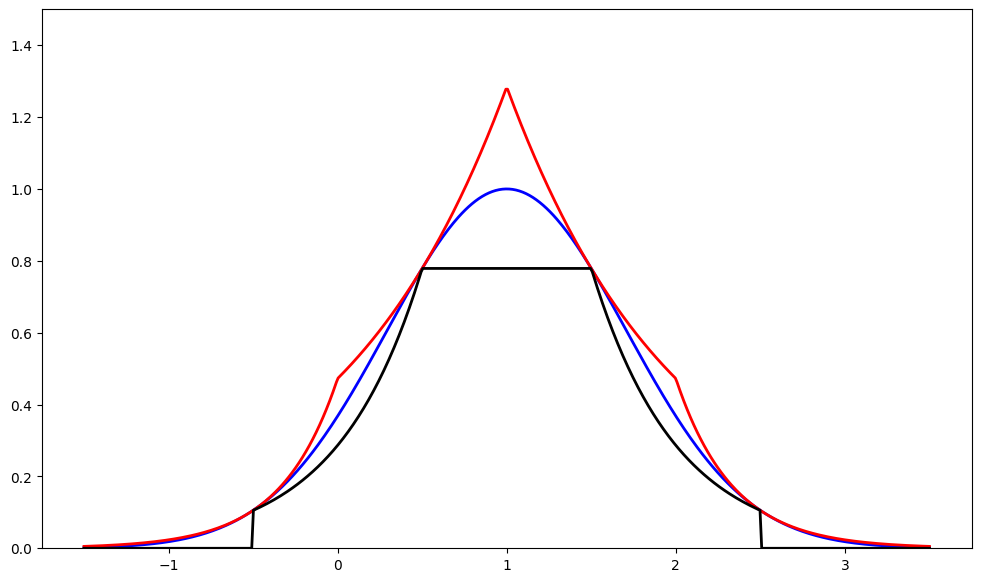

In [4]:
plt.figure(figsize=(12, 7))

x_grafico = np.linspace(-1.5, 3.5, 500)

plt.plot(x_grafico, pdf_objetivo_ars(x_grafico), color='blue', linewidth=2)
plt.plot(x_grafico, np.exp(ln_pdf_envolvente_ars(x_grafico, nodos_x, nodos_y, nodos_dy)), color='red', linewidth=2)
plt.plot(x_grafico, np.exp(funcion_compresion_ars(x_grafico, nodos_x, nodos_y)), color='black', linewidth=2)

plt.ylim(0, 1.5)

plt.savefig("RECHAZO_ADAPTATIVO_2.pdf")
plt.show()

In [5]:
from google.colab import files

files.download("RECHAZO_ADAPTATIVO_1.pdf")
files.download("RECHAZO_ADAPTATIVO_2.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>